In [2]:
import cv2
import torch
import json
import logging
import numpy as np
from PIL import Image
from pathlib import Path
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import onnxruntime as ort
import torchvision.transforms as transforms

import os
import sys
sys.path.append(os.path.abspath('../..'))
# from utils import show_images
from constants import BASE_DIR
from utils import show_images

In [3]:
sample_path = BASE_DIR / 'datasets/celebrities/mo_salah/cleaned/Frame 1.png'
sample_1_path = BASE_DIR / 'datasets/celebrities/mo_salah/cleaned/Frame 2.png'
resolution = (512, 512)
sample = Image.open(sample_path).resize(resolution).convert("RGB")
sample_1 = Image.open(sample_1_path).resize(resolution).convert("RGB")

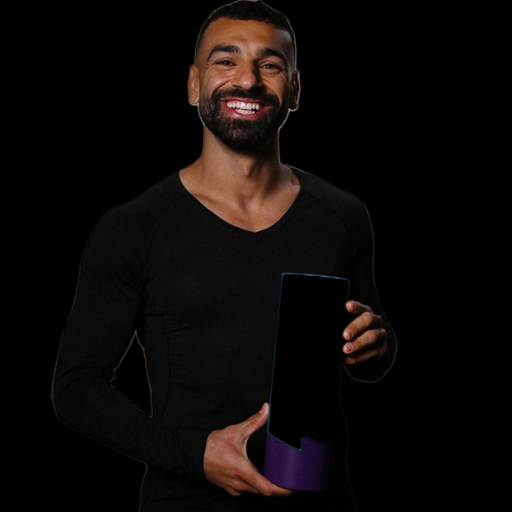

In [4]:
sample

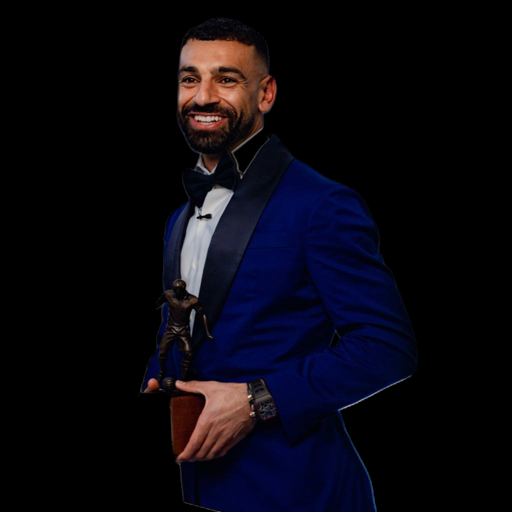

In [5]:
sample_1

# Face Detection

In [6]:
from retinaface import RetinaFace

2025-06-23 20:32:06.051851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 20:32:06.163442: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 20:32:06.198367: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 20:32:06.407300: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-23 20:32:08.043040: W tensorflow/compiler/tf2

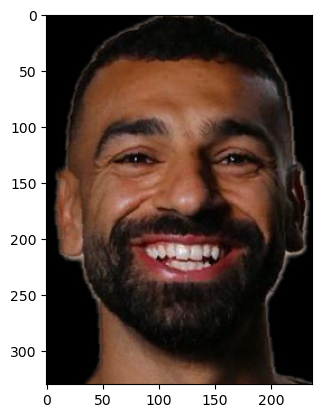

In [35]:
face1 = RetinaFace.extract_faces(sample_path, align=True, expand_face_area=30)
face2 =  RetinaFace.extract_faces(sample_1_path, align=True, expand_face_area=30)
plt.imshow(face1[0])

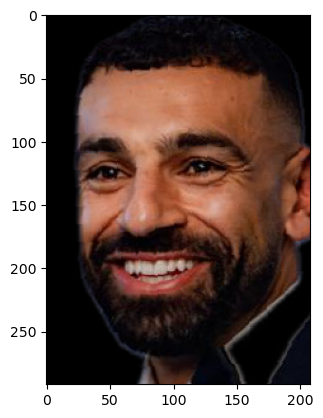

In [ ]:
plt.imshow(face2)

# Face Embeddings

In [ ]:
from deepface import DeepFace

In [ ]:
embedding1 = DeepFace.represent(
    img_path=face1,  # Pass numpy array directly
    model_name="Facenet512",     # Specify FaceNet model
    enforce_detection=False,  # Skip detection since face is pre-extracted
    detector_backend="skip"   # Skip detector for pre-processed face
)[0]['embedding']

embedding2 = DeepFace.represent(
    img_path=face2,  # Pass numpy array directly
    model_name="Facenet512",     # Specify FaceNet model
    enforce_detection=False,  # Skip detection since face is pre-extracted
    detector_backend="skip"   # Skip detector for pre-processed face
)[0]['embedding']

In [ ]:
# len(embedding[0]['embedding'])

# Face Loss

In [ ]:
import torch.nn as nn

id_criterion = nn.CosineEmbeddingLoss()

In [ ]:
embedding1 = torch.tensor(DeepFace.represent(
    img_path=face1,  # Pass numpy array directly
    model_name="Facenet512",     # Specify FaceNet model
    enforce_detection=False,  # Skip detection since face is pre-extracted
    detector_backend="skip"   # Skip detector for pre-processed face
)[0]['embedding']).unsqueeze(0)

embedding2 = torch.tensor(DeepFace.represent(
    img_path=face2,  # Pass numpy array directly
    model_name="Facenet512",     # Specify FaceNet model
    enforce_detection=False,  # Skip detection since face is pre-extracted
    detector_backend="skip"   # Skip detector for pre-processed face
)[0]['embedding']).unsqueeze(0)

loss = id_criterion(embedding1, embedding2, torch.ones(embedding1.shape[0]))

In [ ]:
loss

tensor(0.2161)

#  Batch processing

In [44]:
np.stack([np.array(sample), np.array(sample_1)]).shape

(2, 512, 512, 3)

In [78]:
images =  np.concatenate
# RetinaFace.extract_faces(np.stack([np.array(sample), np.array(sample_1)]), align=True, expand_face_area=30)

## Detection RetinaFace

In [79]:
from retinaface.RetinaFace import build_model
from retinaface.commons import preprocess as retina_preprocess
from deepface.models.facial_recognition.Facenet import FaceNet512dClient, FacialRecognition
from deepface.modules import preprocessing as deepface_preprocessing

In [37]:
retinaface = build_model()

In [80]:
def process_images_retinaface(images: [np.ndarray], resolution = (1024, 1980), allow_upscaling = True):
    cleaned_images = [deepface_preprocessing.resize_image(img, resolution) for img in images]

    return np.concatenate(cleaned_images)

In [81]:
cleaned_imgs = process_images_retinaface([face1[0], face2[0]])

In [85]:
retina_result = retinaface(cleaned_imgs)

9

## Embeddings Facenet

In [56]:
def process_images_facenet(images: [np.ndarray], model: FacialRecognition):
    cleaned_images = [deepface_preprocessing.resize_image(img, model.input_shape) for img in images]
    cleaned_images = [deepface_preprocessing.normalize_input(img) for img in cleaned_images]

    return np.concatenate(cleaned_images)

facenet512 = FaceNet512dClient()

In [57]:
cleaned_imgs = process_images_facenet([face1[0], face2[0]], facenet512)

In [58]:
cleaned_imgs.shape

(2, 160, 160, 3)

In [59]:
facenet512.model(cleaned_imgs)

<tf.Tensor: shape=(2, 512), dtype=float32, numpy=
array([[-0.30368316,  0.809731  ,  0.46701214, ...,  1.2186029 ,
        -0.6914208 , -0.68870735],
       [ 0.39542577,  1.4539162 ,  0.09470269, ...,  1.5167863 ,
        -0.45028558, -0.76254344]], dtype=float32)>